In [20]:
import pandas as pd

df = pd.read_excel(
    "Vehicle_Data_ DwellTime _Tra.xlsx",
    sheet_name="InOut"
)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (77432, 8)

Columns:
['Country', 'Plate Prefix', 'Plate Number', 'Entry Time', 'Exit Time', 'Risk Category', 'Duration in Min', 'Time Taken']


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77432 entries, 0 to 77431
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Country          0 non-null      float64       
 1   Plate Prefix     0 non-null      float64       
 2   Plate Number     0 non-null      float64       
 3   Entry Time       77432 non-null  datetime64[us]
 4   Exit Time        77432 non-null  datetime64[us]
 5   Risk Category    51005 non-null  str           
 6   Duration in Min  77432 non-null  float64       
 7   Time Taken       77432 non-null  str           
dtypes: datetime64[us](2), float64(4), str(2)
memory usage: 4.7 MB


In [22]:
print("Sample records:")
display(df.head(10))

print("\nRisk Category:")
print(df["Risk Category"].value_counts(dropna=False))

print("\nDuration statistics:")
print(df["Duration in Min"].describe())

Sample records:


,Country,Plate Prefix,Plate Number,Entry Time,Exit Time,Risk Category,Duration in Min,Time Taken
0,NaN,NaN,NaN,2026-08-01 00:00:01.807,2026-08-01 01:33:09.439,GREEN,93.13,1 hr 33 min
1,NaN,NaN,NaN,2026-08-01 00:00:38.107,2026-08-01 01:45:43.918,GREEN,105.10,1 hr 45 min
2,NaN,NaN,NaN,2026-08-01 00:00:56.237,2026-08-01 02:15:55.371,GREEN,134.98,2 hr 14 min
3,NaN,NaN,NaN,2026-08-01 00:02:00.193,2026-08-01 01:56:26.812,GREEN,114.45,1 hr 54 min
4,NaN,NaN,NaN,2026-08-01 00:02:50.141,2026-08-01 01:56:07.121,GREEN,113.28,1 hr 53 min
5,NaN,NaN,NaN,2026-08-01 00:03:20.158,2026-08-01 02:11:58.003,GREEN,128.63,2 hr 8 min
6,NaN,NaN,NaN,2026-08-01 00:03:30.484,2026-08-01 03:53:22.084,GREEN,229.87,3 hr 49 min
7,NaN,NaN,NaN,2026-08-01 00:05:46.440,2026-08-01 01:54:51.357,NaN,109.08,1 hr 49 min
8,NaN,NaN,NaN,2026-08-01 00:08:21.647,2026-08-01 07:00:39.205,GREEN,412.30,6 hr 52 min
9,NaN,NaN,NaN,2026-08-01 00:10:15.191,2026-08-01 02:49:39.504,GREEN,159.40,2 hr 39 min



Risk Category:
Risk Category
GREEN    50075
NaN      26427
RED        930
Name: count, dtype: int64

Duration statistics:
count    77432.000000
mean       142.468385
std        137.289910
min          3.600000
25%         54.470000
50%         93.125000
75%        171.550000
max        719.980000
Name: Duration in Min, dtype: float64


## Verify the duration field

Is Duration in Min actually equal to Exit Time - Entry Time?

In [23]:
calculated_duration = (
    df["Exit Time"] - df["Entry Time"]
).dt.total_seconds() / 60

difference = df["Duration in Min"] - calculated_duration

print("Maximum absolute difference:",
      difference.abs().max())

print("\nMean absolute difference:",
      difference.abs().mean())

print("\nRows with difference greater than 0.01 minutes:",
      (difference.abs() > 0.01).sum())

print("\nLargest differences:")
display(
    df.loc[
        difference.abs().nlargest(10).index,
        ["Entry Time", "Exit Time", "Duration in Min"]
    ].assign(
        Calculated_Duration_Min=calculated_duration.loc[
            difference.abs().nlargest(10).index
        ].values,
        Difference_Min=difference.loc[
            difference.abs().nlargest(10).index
        ].values
    )
)

Maximum absolute difference: 0.0116666666667129

Mean absolute difference: 0.004632484416434168

Rows with difference greater than 0.01 minutes: 5271

Largest differences:


,Entry Time,Exit Time,Duration in Min,Calculated_Duration_Min,Difference_Min
347,2026-08-01 07:14:53.026,2026-08-01 11:50:05.526,275.22,275.208333,0.011667
2378,2026-08-02 12:34:41.037,2026-08-02 13:41:32.537,66.87,66.858333,0.011667
3734,2026-08-03 09:39:03.862,2026-08-03 11:42:31.362,123.47,123.458333,0.011667
4720,2026-08-03 22:59:11.901,2026-08-04 00:15:18.401,76.12,76.108333,0.011667
15841,2026-08-10 13:46:33.101,2026-08-10 14:31:57.601,45.42,45.408333,0.011667
20907,2026-08-13 07:24:57.154,2026-08-13 08:09:00.654,44.07,44.058333,0.011667
65891,2026-09-11 03:36:55.571,2026-09-11 05:41:17.071,124.37,124.358333,0.011667
68891,2026-09-12 21:24:03.055,2026-09-12 22:27:27.555,63.42,63.408333,0.011667
72332,2026-09-15 03:50:26.901,2026-09-15 05:49:54.401,119.47,119.458333,0.011667
74769,2026-09-16 14:08:16.652,2026-09-16 14:58:02.152,49.77,49.758333,0.011667


## Verify Timestamp quality

In [24]:
print("Entry Time missing:", df["Entry Time"].isna().sum())
print("Exit Time missing:", df["Exit Time"].isna().sum())

print("\nEntry >= Exit:")
print((df["Entry Time"] >= df["Exit Time"]).sum())

print("\nEarliest Entry:", df["Entry Time"].min())
print("Latest Entry:", df["Entry Time"].max())

print("\nEarliest Exit:", df["Exit Time"].min())
print("Latest Exit:", df["Exit Time"].max())

Entry Time missing: 0
Exit Time missing: 0

Entry >= Exit:
0

Earliest Entry: 2026-08-01 00:00:01.807000
Latest Entry: 2026-09-17 23:59:41.562000

Earliest Exit: 2026-08-01 01:33:09.439000
Latest Exit: 2026-09-18 10:24:02.478000


## step 1 findings 

We now have a clear understanding of the raw InOut dataset:

* 77,432 vehicle records
* Entry and exit timestamps are complete
* No records have Entry Time >= Exit Time
* Duration in Min is internally consistent with the timestamps, so we will use the provided  column directly
* Risk Category: GREEN, RED, and missing
* Country, Plate Prefix, Plate Number: completely unavailable, so we exclude them
* Time Taken: redundant with Duration in Min, so we exclude it
* Data covers entries from August 1, 2026 through September 17, 2026
* Exits extend into September 18, 2026, which we'll account for when checking coverage

# Data Quality Assessment

In [25]:
quality = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(dropna=True)
})

print("DATA QUALITY SUMMARY")
display(quality)

print("\nDuplicate complete rows:", df.duplicated().sum())

print(
    "Duration <= 0:",
    (df["Duration in Min"] <= 0).sum()
)

print("\nRisk Category values:")
print(df["Risk Category"].value_counts(dropna=False))

DATA QUALITY SUMMARY


,missing,missing_%,unique
Country,77432,100.00,0
Plate Prefix,77432,100.00,0
Plate Number,77432,100.00,0
Entry Time,0,0.00,77432
Exit Time,0,0.00,77432
Risk Category,26427,34.13,2
Duration in Min,0,0.00,22229
Time Taken,0,0.00,717



Duplicate complete rows: 0
Duration <= 0: 0

Risk Category values:
Risk Category
GREEN    50075
NaN      26427
RED        930
Name: count, dtype: int64


In [26]:
duplicate_events = df.duplicated(
    subset=["Entry Time", "Exit Time"],
    keep=False
)

print("Rows involved in repeated Entry/Exit pairs:", duplicate_events.sum())

if duplicate_events.sum() > 0:
    display(
        df.loc[
            duplicate_events,
            ["Entry Time", "Exit Time", "Risk Category", "Duration in Min"]
        ].sort_values(["Entry Time", "Exit Time"]).head(20)
    )

Rows involved in repeated Entry/Exit pairs: 0


In [27]:
daily_entries = df.groupby(
    df["Entry Time"].dt.date
).size()

display(daily_entries.tail(10))

print("\nLast entry date:", df["Entry Time"].dt.date.max())
print("Entries on last date:", daily_entries.iloc[-1])

print(
    "\nLatest entry time on last date:",
    df.loc[
        df["Entry Time"].dt.date == df["Entry Time"].dt.date.max(),
        "Entry Time"
    ].max()
)

Entry Time
2026-09-08    1749
2026-09-09    1820
2026-09-10    1915
2026-09-11    1772
2026-09-12    1629
2026-09-13    1615
2026-09-14    1519
2026-09-15    1700
2026-09-16    1703
2026-09-17    1821
dtype: int64


Last entry date: 2026-09-17
Entries on last date: 1821

Latest entry time on last date: 2026-09-17 23:59:41.562000


### Data quality conclusion

Keep

Entry Time, Exit Time, Risk Category, Duration in Min

These are useful for the business problem.

Exclude

Country, Plate Prefix, Plate Number

They contain no values, so they cannot contribute useful information.

Time Taken

It is redundant with Duration in Min.

Missing Risk Category

We have:

* GREEN    50,075
* RED         930
* UNKNOWN   26,427

We will eventually convert the missing values to:

**UNKNOWN**

We are not deleting those rows because those records still contain valid entry, exit, and duration information that is valuable for reconstructing occupancy.

Duplicate handling
Exact duplicate rows → 0
Repeated Entry + Exit combinations → 0
We cannot perform true vehicle-ID duplicate detection because vehicle identifiers were not provided.
Timestamp validity
Missing Entry Time → 0
Missing Exit Time → 0
Entry ≥ Exit → 0
Duration validity
Duration ≤ 0 → 0
Provided Duration in Min agrees closely with the timestamps, so we'll use the supplied duration directly rather than repeatedly recalculating it.

# Dwell-Time Analysis

In [28]:
dwell_stats = df["Duration in Min"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(dwell_stats)

count    77432.000000
mean       142.468385
std        137.289910
min          3.600000
25%         54.470000
50%         93.125000
75%        171.550000
90%        327.979000
95%        471.498000
99%        655.149400
max        719.980000
Name: Duration in Min, dtype: float64

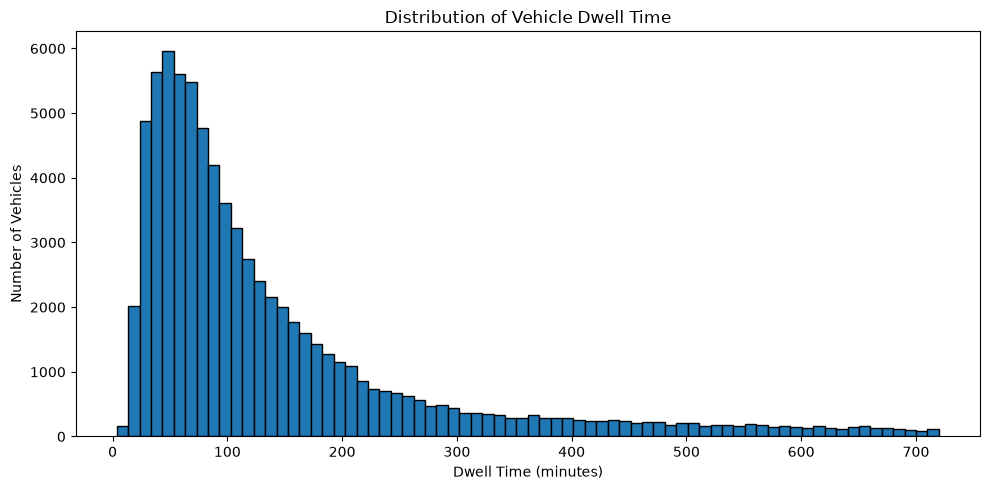

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df["Duration in Min"],
    bins=72,
    edgecolor="black"
)

plt.xlabel("Dwell Time (minutes)")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Vehicle Dwell Time")

plt.tight_layout()
plt.show()

## 3. Dwell-Time Analysis

Vehicle dwell time represents the duration for which a vehicle remains inside the observed system. The analysis uses the provided `Duration in Min` field.

The purpose of this analysis is to understand the typical vehicle stay duration, the variability of dwell times, and the presence of long-duration observations that may influence system occupancy.

The analysis examines descriptive statistics, distribution shape, and the apparent upper boundary near 720 minutes.

### Descriptive statistics

The median dwell time is used as an indicator of a typical vehicle stay, while higher percentiles such as P90, P95, and P99 are used to understand the upper tail of the distribution.

This is particularly relevant to occupancy forecasting because vehicles with long dwell times can remain in the system for an extended period and therefore contribute to sustained occupancy.


In [30]:
upper_dwell = df.loc[
    df["Duration in Min"] >= 600,
    "Duration in Min"
]

print("Vehicles with dwell >= 600 min:", len(upper_dwell))
print(
    "Percentage of all vehicles:",
    round(len(upper_dwell) / len(df) * 100, 2),
)

print("\nUpper-tail percentiles:")
print(
    upper_dwell.quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nVehicles with dwell >= 700 min:",
      (df["Duration in Min"] >= 700).sum())

print("Vehicles with dwell >= 710 min:",
      (df["Duration in Min"] >= 710).sum())

print("Vehicles with dwell >= 719 min:",
      (df["Duration in Min"] >= 719).sum())

print("Vehicles with dwell >= 719.9 min:",
      (df["Duration in Min"] >= 719.9).sum())

print("\nLargest observed dwell values:")
display(
    df["Duration in Min"]
    .nlargest(20)
    .to_frame()
    .reset_index(drop=True)
)

Vehicles with dwell >= 600 min: 1551
Percentage of all vehicles: 2.0

Upper-tail percentiles:
0.50    654.970
0.75    683.405
0.90    705.550
0.95    713.065
0.99    719.175
Name: Duration in Min, dtype: float64

Vehicles with dwell >= 700 min: 206
Vehicles with dwell >= 710 min: 113
Vehicles with dwell >= 719 min: 19
Vehicles with dwell >= 719.9 min: 3

Largest observed dwell values:


,Duration in Min
0,719.98
1,719.97
2,719.90
3,719.82
4,719.77
5,719.77
6,719.72
7,719.70
8,719.67
9,719.63


In [33]:
extreme_threshold = 600

df["Extreme Dwell"] = (
    df["Duration in Min"] >= extreme_threshold
)

extreme_by_risk = (
    df.groupby("Risk Category", dropna=False)
      .agg(
          total_vehicles=("Duration in Min", "size"),
          extreme_vehicles=("Extreme Dwell", "sum")
      )
)

extreme_by_risk["extreme_percentage"] = (
    extreme_by_risk["extreme_vehicles"]
    / extreme_by_risk["total_vehicles"]
    * 100
).round(2)

display(extreme_by_risk)

,total_vehicles,extreme_vehicles,extreme_percentage
Risk Category,,,
GREEN,50075,1057,2.11
RED,930,29,3.12
NaN,26427,465,1.76


In [34]:
risk_dwell = (
    df.groupby("Risk Category", dropna=False)["Duration in Min"]
      .agg(
          count="count",
          median="median",
          p75=lambda x: x.quantile(0.75),
          p90=lambda x: x.quantile(0.90),
          p95=lambda x: x.quantile(0.95)
      )
      .round(2)
)

display(risk_dwell)

,count,median,p75,p90,p95
Risk Category,,,,,
GREEN,50075,104.03,189.84,356.26,487.32
RED,930,136.82,236.34,396.41,550.69
NaN,26427,75.13,132.65,257.37,427.25


## 3. Dwell-Time Analysis

Vehicle dwell time represents the duration for which a vehicle remains inside the observed system. The analysis uses the provided `Duration in Min` field.

The purpose of this analysis is to understand typical vehicle stay duration, variability, the upper tail of the distribution, and whether dwell behavior differs across relevant categories.

### 3.1 Descriptive Statistics

The observed median dwell time is **93.13 minutes**, while the mean is **142.47 minutes**. The difference between the mean and median, together with the distribution shape, indicates a strongly right-skewed dwell-time distribution.

| Statistic | Dwell Time (minutes) |
|---|---:|
| Minimum | 3.60 |
| P25 | 54.47 |
| P50 (Median) | 93.13 |
| P75 | 171.55 |
| P90 | 327.98 |
| P95 | 471.50 |
| P99 | 655.15 |
| Maximum | 719.98 |

The upper percentiles show a substantial long-duration tail. Approximately 10% of vehicles have dwell times above 327.98 minutes, while approximately 1% exceed 655.15 minutes.

### 3.2 Distribution Shape

The dwell-time histogram shows that most observations are concentrated at lower dwell durations, followed by a long right tail extending toward 720 minutes.

This long tail is relevant to occupancy forecasting because vehicles with long dwell times can remain inside the system for extended periods and contribute to sustained active-vehicle counts.

### 3.3 Apparent Upper Boundary

The observed dwell times terminate close to **720 minutes**. Approximately 2% of records have dwell times of at least 600 minutes, while only a small number approach 720 minutes.

The data therefore suggests an apparent upper boundary near 720 minutes. However, the dataset alone does not establish whether this represents an operational limit, censoring, a data-generation rule, or another business constraint.

These observations are therefore retained rather than automatically treated as invalid outliers.

### 3.3 Dwell Time by Risk Category

Dwell-time distributions were compared across the available `Risk Category` values.

The `RED` category showed consistently higher dwell-time statistics than `GREEN`, including the median, P75, P90, and P95. This pattern is also consistent with the higher proportion of extreme dwell observations observed for `RED`.

The missing-category group showed lower dwell-time statistics. However, these records represent cases where risk information was unavailable and should not be interpreted as a separate business category.

The observed differences indicate that `Risk Category` may contain useful information related to dwell behavior. It will therefore be retained as a candidate feature for later forecasting experiments. Whether it improves predictive performance will be determined through chronological model validation rather than assumed from this descriptive analysis.

In [35]:
df["Entry Date"] = df["Entry Time"].dt.date
df["Entry Hour"] = df["Entry Time"].dt.hour
df["Entry Day"] = df["Entry Time"].dt.day_name()

print("Date range:")
print(df["Entry Date"].min(), "->", df["Entry Date"].max())

print("\nHours:")
print(sorted(df["Entry Hour"].unique()))

print("\nDays of week:")
print(df["Entry Day"].unique())

Date range:
2026-08-01 -> 2026-09-17

Hours:
[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]

Days of week:
<StringArray>
['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 7, dtype: str


## 4. Arrival Analysis

Arrival analysis examines when vehicles enter the observed system and how traffic volume changes over time.

Understanding arrival demand is important for occupancy forecasting because vehicle accumulation depends partly on the rate at which new vehicles enter the system.

The analysis separates:

- **Total traffic:** total number of arrivals observed during a period.
- **Average traffic:** typical arrival volume across comparable periods.
- **Peak traffic:** periods with unusually high arrival volume.

Time information is derived from `Entry Time` to support daily, hourly, weekday, and weekly analysis.

In [36]:
daily_arrivals = (
    df.groupby("Entry Date")
      .size()
      .rename("arrivals")
)

print("Average daily arrivals:", round(daily_arrivals.mean(), 2))
print("Minimum daily arrivals:", daily_arrivals.min())
print("Maximum daily arrivals:", daily_arrivals.max())

print("\nDaily arrival statistics:")
display(daily_arrivals.describe())

print("\nHighest-volume days:")
display(daily_arrivals.nlargest(10))

print("\nLowest-volume days:")
display(daily_arrivals.nsmallest(10))

Average daily arrivals: 1613.17
Minimum daily arrivals: 1
Maximum daily arrivals: 2173

Daily arrival statistics:


count      48.000000
mean     1613.166667
std       359.647010
min         1.000000
25%      1565.750000
50%      1700.500000
75%      1790.750000
max      2173.000000
Name: arrivals, dtype: float64


Highest-volume days:


Entry Date
2026-08-18    2173
2026-08-14    1954
2026-08-11    1942
2026-08-12    1916
2026-09-10    1915
2026-08-20    1899
2026-09-02    1847
2026-08-28    1845
2026-08-10    1844
2026-09-17    1821
Name: arrivals, dtype: int64


Lowest-volume days:


Entry Date
2026-08-23       1
2026-08-22     416
2026-08-27    1181
2026-09-05    1252
2026-08-15    1261
2026-08-31    1291
2026-08-21    1350
2026-08-29    1364
2026-08-24    1441
2026-08-01    1480
Name: arrivals, dtype: int64

In [37]:
for date in ["2026-08-22", "2026-08-23"]:
    day_data = df[df["Entry Time"].dt.strftime("%Y-%m-%d") == date]

    print("\n" + "=" * 60)
    print(f"Date: {date}")
    print("Number of arrivals:", len(day_data))

    if len(day_data) > 0:
        print("First entry:", day_data["Entry Time"].min())
        print("Last entry :", day_data["Entry Time"].max())

        print("\nHourly arrivals:")
        print(
            day_data["Entry Time"]
            .dt.hour
            .value_counts()
            .sort_index()
        )


Date: 2026-08-22
Number of arrivals: 416
First entry: 2026-08-22 00:00:31.334000
Last entry : 2026-08-22 09:57:19.208000

Hourly arrivals:
Entry Time
0    35
1    70
2    42
3    34
4    58
5    18
6    48
7    44
8    41
9    26
Name: count, dtype: int64

Date: 2026-08-23
Number of arrivals: 1
First entry: 2026-08-23 22:14:56.045000
Last entry : 2026-08-23 22:14:56.045000

Hourly arrivals:
Entry Time
22    1
Name: count, dtype: int64


In [38]:
daily_coverage = (
    df.groupby("Entry Date")
      .agg(
          arrivals=("Entry Time", "size"),
          first_entry=("Entry Time", "min"),
          last_entry=("Entry Time", "max"),
          active_hours=("Entry Hour", "nunique")
      )
)

display(daily_coverage)

,arrivals,first_entry,last_entry,active_hours
Entry Date,,,,
2026-08-01,1480,2026-08-01 00:00:01.807,2026-08-01 23:56:45.185,24
2026-08-02,1707,2026-08-02 00:02:14.934,2026-08-02 23:51:30.568,24
2026-08-03,1577,2026-08-03 00:03:06.447,2026-08-03 23:59:37.464,24
2026-08-04,1664,2026-08-04 00:02:45.051,2026-08-04 23:59:47.707,24
2026-08-05,1701,2026-08-05 00:03:40.402,2026-08-05 23:59:39.997,24
2026-08-06,1671,2026-08-06 00:00:07.653,2026-08-06 23:59:29.205,24
2026-08-07,1685,2026-08-07 00:02:25.626,2026-08-07 23:59:52.454,24
2026-08-08,1610,2026-08-08 00:01:49.001,2026-08-08 23:59:40.326,24
2026-08-09,1768,2026-08-09 00:00:04.260,2026-08-09 23:59:37.685,24


In [39]:
display(
    daily_coverage.sort_values("active_hours").head(10)
)

display(
    daily_coverage.sort_values("arrivals").head(10)
)

,arrivals,first_entry,last_entry,active_hours
Entry Date,,,,
2026-08-23,1,2026-08-23 22:14:56.045,2026-08-23 22:14:56.045,1
2026-08-22,416,2026-08-22 00:00:31.334,2026-08-22 09:57:19.208,10
2026-08-26,1731,2026-08-26 00:03:28.901,2026-08-26 23:59:02.214,22
2026-08-27,1181,2026-08-27 00:00:37.549,2026-08-27 23:59:28.082,22
2026-08-01,1480,2026-08-01 00:00:01.807,2026-08-01 23:56:45.185,24
2026-08-02,1707,2026-08-02 00:02:14.934,2026-08-02 23:51:30.568,24
2026-08-03,1577,2026-08-03 00:03:06.447,2026-08-03 23:59:37.464,24
2026-08-04,1664,2026-08-04 00:02:45.051,2026-08-04 23:59:47.707,24
2026-08-09,1768,2026-08-09 00:00:04.260,2026-08-09 23:59:37.685,24


,arrivals,first_entry,last_entry,active_hours
Entry Date,,,,
2026-08-23,1,2026-08-23 22:14:56.045,2026-08-23 22:14:56.045,1
2026-08-22,416,2026-08-22 00:00:31.334,2026-08-22 09:57:19.208,10
2026-08-27,1181,2026-08-27 00:00:37.549,2026-08-27 23:59:28.082,22
2026-09-05,1252,2026-09-05 00:03:16.914,2026-09-05 23:59:21.221,24
2026-08-15,1261,2026-08-15 00:04:26.652,2026-08-15 23:59:49.126,24
2026-08-31,1291,2026-08-31 00:03:07.236,2026-08-31 23:59:54.624,24
2026-08-21,1350,2026-08-21 00:01:47.127,2026-08-21 23:58:21.419,24
2026-08-29,1364,2026-08-29 00:00:06.911,2026-08-29 23:59:35.510,24
2026-08-24,1441,2026-08-24 00:42:07.551,2026-08-24 23:59:54.521,24


In [40]:
for date in ["2026-08-26", "2026-08-27"]:
    day_data = df[df["Entry Date"] == pd.to_datetime(date).date()]

    hourly_counts = (
        day_data["Entry Hour"]
        .value_counts()
        .sort_index()
        .reindex(range(24), fill_value=0)
    )

    print("\n" + "=" * 60)
    print(f"Date: {date}")
    print(hourly_counts)


Date: 2026-08-26
Entry Hour
0      59
1      61
2      84
3      74
4      25
5       0
6       0
7      20
8      85
9     103
10    116
11     98
12    124
13     90
14    114
15    128
16     78
17    119
18     46
19     64
20     45
21     77
22     50
23     71
Name: count, dtype: int64

Date: 2026-08-27
Entry Hour
0      34
1      19
2       0
3       3
4       3
5       6
6       5
7      40
8      21
9       0
10     63
11     44
12     72
13     76
14     43
15     49
16     87
17    124
18    146
19     68
20     52
21     87
22     84
23     55
Name: count, dtype: int64


### 4.2 Daily Arrival Coverage

Daily arrival counts showed substantial variation across the observation period.

Two dates were identified as clearly incomplete based on entry-time coverage:

- **August 22, 2026:** observations stopped at approximately 10:00 AM.
- **August 23, 2026:** only one entry was recorded.

These dates should not be treated as complete daily observations when calculating daily or weekly traffic patterns.

August 26 and August 27 contained observations throughout most of the day but had only 22 distinct hours with recorded arrivals. These dates were therefore investigated separately to determine whether the missing hours represented genuine zero-arrival periods or possible data-collection gaps.

###  Daily Arrival Volume

Daily arrival volume was calculated using only dates with complete entry-time coverage.

August 22 and August 23 were excluded from daily traffic-pattern calculations because their entry observations did not cover the full day. The underlying vehicle records were retained and were not deleted from the dataset.

This distinction is important because incomplete observation days can artificially reduce daily traffic estimates and distort comparisons across weekdays and weeks.

Daily traffic was therefore summarized using the remaining complete observation days.

In [41]:
incomplete_dates = [
    pd.to_datetime("2026-08-22").date(),
    pd.to_datetime("2026-08-23").date()
]

complete_day_df = df[
    ~df["Entry Date"].isin(incomplete_dates)
]

daily_arrivals = (
    complete_day_df
    .groupby("Entry Date")
    .size()
    .rename("arrivals")
)

print("Complete days:", len(daily_arrivals))
print("Average daily arrivals:", round(daily_arrivals.mean(), 2))
print("Minimum daily arrivals:", daily_arrivals.min())
print("Maximum daily arrivals:", daily_arrivals.max())

print("\nHighest-volume days:")
display(daily_arrivals.nlargest(5))

print("\nLowest-volume days:")
display(daily_arrivals.nsmallest(5))

Complete days: 46
Average daily arrivals: 1674.24
Minimum daily arrivals: 1181
Maximum daily arrivals: 2173

Highest-volume days:


Entry Date
2026-08-18    2173
2026-08-14    1954
2026-08-11    1942
2026-08-12    1916
2026-09-10    1915
Name: arrivals, dtype: int64


Lowest-volume days:


Entry Date
2026-08-27    1181
2026-09-05    1252
2026-08-15    1261
2026-08-31    1291
2026-08-21    1350
Name: arrivals, dtype: int64

###  Daily Arrival Pattern

Across the 46 complete observation days, the average daily arrival volume was **1,674 vehicles**, with daily counts ranging from **1,181 to 2,173 vehicles**.

The highest observed complete day was **August 18, 2026**, with 2,173 arrivals, while the lowest was **August 27, 2026**, with 1,181 arrivals.

The daily time series is visualized to identify broad changes and recurring patterns in demand. Individual high- or low-volume days are not classified as anomalies at this stage because their interpretation depends on weekday and temporal patterns examined later.

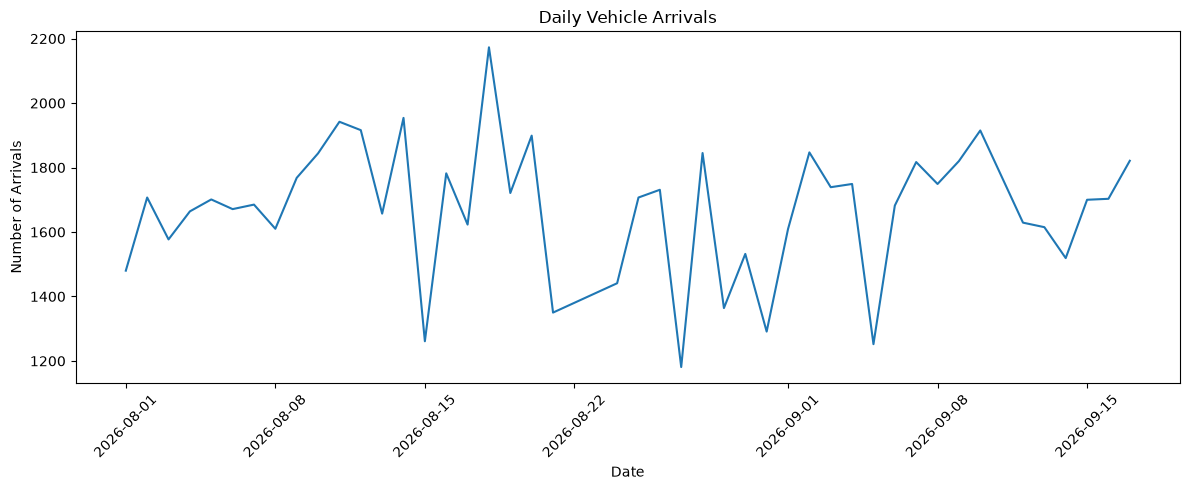

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_arrivals.index,
    daily_arrivals.values
)

plt.xlabel("Date")
plt.ylabel("Number of Arrivals")
plt.title("Daily Vehicle Arrivals")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hourly Arrival Pattern

Hourly arrival volume was analyzed using the complete observation days to understand the typical intraday demand pattern.

For each hour of the day, the average number of vehicle arrivals was calculated across the complete days.

This analysis is important for the forecasting problem because arrival demand may vary substantially throughout the day, creating recurring patterns that can influence future active-vehicle occupancy.

In [43]:
hourly_arrivals = (
    complete_day_df
    .groupby("Entry Hour")
    .size()
)

# Average arrivals per hour across complete days
hourly_avg = (
    hourly_arrivals / daily_arrivals.shape[0]
).round(2)

print("Average arrivals by hour:")
display(hourly_avg)

print("\nBusiest hour:")
print(hourly_avg.idxmax(), ":", hourly_avg.max(), "average arrivals")

print("\nQuietest hour:")
print(hourly_avg.idxmin(), ":", hourly_avg.min(), "average arrivals")

Average arrivals by hour:


Entry Hour
0     50.87
1     57.59
2     55.67
3     56.26
4     47.33
5     44.61
6     61.61
7     67.80
8     59.91
9     68.52
10    87.65
11    89.07
12    90.85
13    86.54
14    87.35
15    87.59
16    73.22
17    83.41
18    86.91
19    66.59
20    62.52
21    73.78
22    64.09
23    64.50
dtype: float64


Busiest hour:
12 : 90.85 average arrivals

Quietest hour:
5 : 44.61 average arrivals


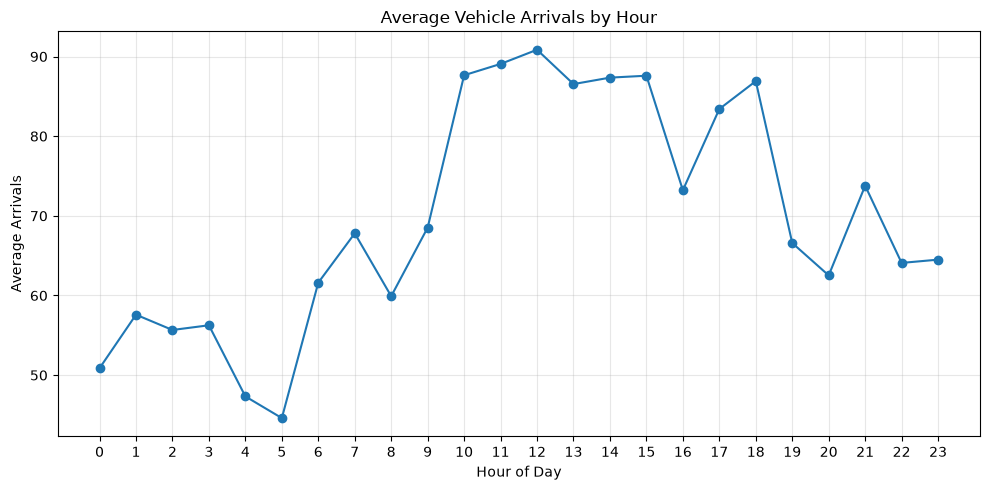

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_avg.index,
    hourly_avg.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Arrivals")
plt.title("Average Vehicle Arrivals by Hour")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

###  Hourly Arrival Pattern

Hourly arrival volume was analyzed across the complete observation days to identify recurring intraday demand patterns.

The average number of arrivals varies considerably by hour. Demand is relatively low during the early morning and increases during the late-morning period, reaching its highest average at **12:00–12:59 with approximately 90.9 arrivals**. The arrival rate remains relatively high through much of the afternoon before declining later in the day.

This indicates a clear intraday demand pattern that may be relevant for future occupancy forecasting. The pattern will be examined further alongside day-of-week effects to determine whether temporal features provide useful predictive information.

###  Day-of-Week Arrival Pattern

Arrival volume was compared across the seven days of the week using complete observation days.

Both total arrivals and the number of observed days were retained for context. For comparing typical traffic levels between weekdays, **average arrivals per complete observed day** was used because the number of observations is not identical for every weekday.

This analysis is intended to identify recurring weekly demand differences that may be useful for forecasting future active-vehicle occupancy.

In [45]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_arrivals = (
    complete_day_df
    .groupby("Entry Day")
    .agg(
        total_arrivals=("Entry Time", "size"),
        observed_days=("Entry Date", "nunique")
    )
)

weekday_arrivals["average_arrivals"] = (
    weekday_arrivals["total_arrivals"]
    / weekday_arrivals["observed_days"]
)

weekday_arrivals = (
    weekday_arrivals
    .reindex(day_order)
    .round(2)
)

display(weekday_arrivals)

print(
    "\nBusiest weekday by average:",
    weekday_arrivals["average_arrivals"].idxmax()
)

print(
    "Average arrivals:",
    weekday_arrivals["average_arrivals"].max()
)

print(
    "\nQuietest weekday by average:",
    weekday_arrivals["average_arrivals"].idxmin()
)

print(
    "Average arrivals:",
    weekday_arrivals["average_arrivals"].min()
)

,total_arrivals,observed_days,average_arrivals
Entry Day,,,
Monday,11112,7,1587.43
Tuesday,12544,7,1792.00
Wednesday,12439,7,1777.00
Thursday,11883,7,1697.57
Friday,10355,6,1725.83
Saturday,8596,6,1432.67
Sunday,10086,6,1681.00



Busiest weekday by average: Tuesday
Average arrivals: 1792.0

Quietest weekday by average: Saturday
Average arrivals: 1432.67


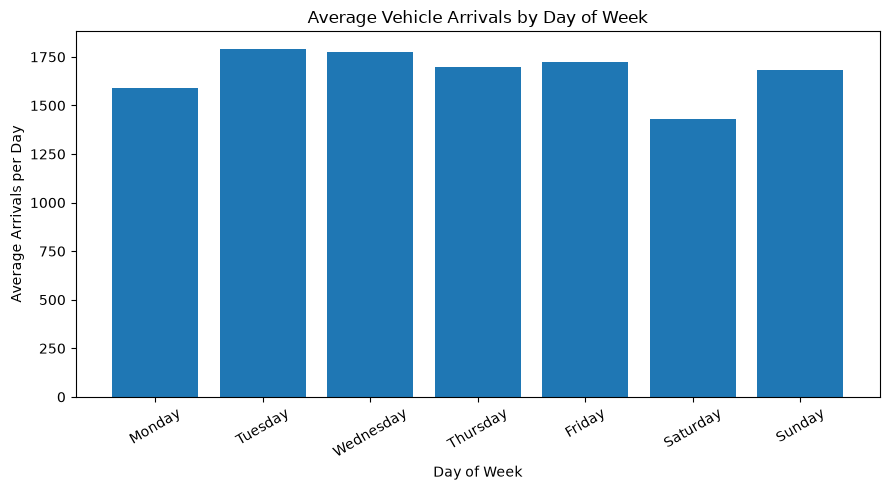

In [46]:
plt.figure(figsize=(9, 5))

plt.bar(
    weekday_arrivals.index,
    weekday_arrivals["average_arrivals"]
)

plt.xlabel("Day of Week")
plt.ylabel("Average Arrivals per Day")
plt.title("Average Vehicle Arrivals by Day of Week")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

###  Day-of-Week Arrival Pattern

Average arrival volume varies across days of the week.

Among the complete observed days, Tuesday had the highest average arrival volume at **1,792 vehicles per day**, while Saturday had the lowest at **1,432.67 vehicles per day**. The difference between these averages is approximately 359 vehicles per day.

The observed pattern suggests that day of week may contain useful information about expected arrival demand. However, the dataset contains a limited number of complete observations for each weekday, so these differences are treated as descriptive rather than as a definitive long-term business pattern.

## 5. Reconstruct Active Vehicle Count / In-System Occupancy

The raw dataset does not contain a direct measurement of physical queue length. Instead, active vehicle count is reconstructed from vehicle entry and exit timestamps.

For each vehicle:

- an entry contributes **+1**
- an exit contributes **-1**

The cumulative balance of these events represents the number of vehicles currently inside the observed system.

\[
A_t = A_{t-1} + E_t - X_t
\]

where \(A_t\) represents active vehicles, \(E_t\) represents entries, and \(X_t\) represents exits.

This quantity is referred to as **active vehicle count** or **in-system occupancy** throughout the analysis. It is used as a proxy for congestion because the dataset does not contain a direct physical queue-length measurement.

Before aggregating the data into forecasting intervals, the reconstructed event stream is checked to ensure that the cumulative active count does not become negative.

In [47]:
entries = df[["Entry Time"]].copy()
entries["change"] = 1

exits = df[["Exit Time"]].copy()
exits["change"] = -1

events = pd.concat(
    [
        entries.rename(columns={"Entry Time": "timestamp"}),
        exits.rename(columns={"Exit Time": "timestamp"})
    ],
    ignore_index=True
)

events = (
    events
    .groupby("timestamp", as_index=False)["change"]
    .sum()
    .sort_values("timestamp")
)

events["active_vehicles"] = events["change"].cumsum()

print("Minimum active vehicle count:",
      events["active_vehicles"].min())

print("Maximum active vehicle count:",
      events["active_vehicles"].max())

print("\nFirst 10 event states:")
display(events.head(10))

Minimum active vehicle count: 0
Maximum active vehicle count: 500

First 10 event states:


,timestamp,change,active_vehicles
0,2026-08-01 00:00:01.807,1,1
1,2026-08-01 00:00:38.107,1,2
2,2026-08-01 00:00:56.237,1,3
3,2026-08-01 00:02:00.193,1,4
4,2026-08-01 00:02:50.141,1,5
5,2026-08-01 00:03:20.158,1,6
6,2026-08-01 00:03:30.484,1,7
7,2026-08-01 00:05:46.440,1,8
8,2026-08-01 00:08:21.647,1,9
9,2026-08-01 00:10:15.191,1,10


In [48]:
# Create 15-minute bucket for each entry and exit
df["Entry Bucket"] = df["Entry Time"].dt.floor("15min")
df["Exit Bucket"] = df["Exit Time"].dt.floor("15min")

# Count arrivals in each bucket
arrivals_15min = (
    df.groupby("Entry Bucket")
      .size()
      .rename("arrivals")
)

# Count exits in each bucket
exits_15min = (
    df.groupby("Exit Bucket")
      .size()
      .rename("exits")
)

# Combine both event counts
occupancy_15min = pd.concat(
    [arrivals_15min, exits_15min],
    axis=1
).fillna(0)

# Net flow
occupancy_15min["net_flow"] = (
    occupancy_15min["arrivals"]
    - occupancy_15min["exits"]
)

# Reconstruct active vehicles
occupancy_15min["active_vehicles"] = (
    occupancy_15min["net_flow"].cumsum()
)

# Make sure the index is sorted
occupancy_15min = occupancy_15min.sort_index()

display(occupancy_15min.head(10))

/tmp/ipykernel_10973/3503232030.py:20: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  occupancy_15min = pd.concat(


,arrivals,exits,net_flow,active_vehicles
2026-08-01 00:00:00,17.0,0.0,17.0,17.0
2026-08-01 00:15:00,7.0,0.0,7.0,24.0
2026-08-01 00:30:00,10.0,0.0,10.0,34.0
2026-08-01 00:45:00,17.0,0.0,17.0,51.0
2026-08-01 01:00:00,27.0,0.0,27.0,78.0
2026-08-01 01:15:00,10.0,0.0,10.0,88.0
2026-08-01 01:30:00,13.0,1.0,12.0,100.0
2026-08-01 01:45:00,11.0,12.0,-1.0,99.0
2026-08-01 02:00:00,17.0,4.0,13.0,112.0
2026-08-01 02:15:00,2.0,11.0,-9.0,103.0


In [49]:
print("Minimum active vehicles:",
      occupancy_15min["active_vehicles"].min())

print("Maximum active vehicles:",
      occupancy_15min["active_vehicles"].max())

print("\nNumber of 15-minute intervals:",
      len(occupancy_15min))

print("\nTotal arrivals:",
      occupancy_15min["arrivals"].sum())

print("Total exits:",
      occupancy_15min["exits"].sum())

Minimum active vehicles: 0.0
Maximum active vehicles: 493.0

Number of 15-minute intervals: 4462

Total arrivals: 77432.0
Total exits: 77432.0


### 5.1 Constructing a 15-Minute Occupancy Time Series

Vehicle entry and exit events were aggregated into 15-minute intervals.

For each interval:

- `arrivals` = number of vehicle entries
- `exits` = number of vehicle exits
- `net_flow` = arrivals − exits
- `active_vehicles` = cumulative net flow

The resulting series uses a regular 15-minute time interval. Missing intervals with no vehicle events are explicitly represented with zero arrivals and zero exits.

The timestamp represents the **end of the 15-minute interval**. Therefore, the `active_vehicles` value at a timestamp represents the reconstructed number of vehicles in the system at that interval boundary.

This produces a regular occupancy time series suitable for subsequent congestion analysis and forecasting.

In [50]:
# 15-minute buckets
df["Entry Bucket"] = df["Entry Time"].dt.floor("15min")
df["Exit Bucket"] = df["Exit Time"].dt.floor("15min")

# Arrivals and exits per bucket
arrivals_15min = (
    df.groupby("Entry Bucket")
      .size()
      .rename("arrivals")
)

exits_15min = (
    df.groupby("Exit Bucket")
      .size()
      .rename("exits")
)

# Combine event counts
occupancy_15min = pd.concat(
    [arrivals_15min, exits_15min],
    axis=1,
    sort=False
).fillna(0)

occupancy_15min["net_flow"] = (
    occupancy_15min["arrivals"]
    - occupancy_15min["exits"]
)

# Create a complete 15-minute time index
full_index = pd.date_range(
    start=occupancy_15min.index.min(),
    end=occupancy_15min.index.max(),
    freq="15min"
)

occupancy_15min = (
    occupancy_15min
    .reindex(full_index, fill_value=0)
)

# Recalculate active occupancy on the complete time series
occupancy_15min["active_vehicles"] = (
    occupancy_15min["net_flow"].cumsum()
)

# Shift labels from bucket start to bucket end
occupancy_15min.index = occupancy_15min.index + pd.Timedelta(minutes=15)

occupancy_15min.index.name = "timestamp"

display(occupancy_15min.head(10))

,arrivals,exits,net_flow,active_vehicles
timestamp,,,,
2026-08-01 00:15:00,17.0,0.0,17.0,17.0
2026-08-01 00:30:00,7.0,0.0,7.0,24.0
2026-08-01 00:45:00,10.0,0.0,10.0,34.0
2026-08-01 01:00:00,17.0,0.0,17.0,51.0
2026-08-01 01:15:00,27.0,0.0,27.0,78.0
2026-08-01 01:30:00,10.0,0.0,10.0,88.0
2026-08-01 01:45:00,13.0,1.0,12.0,100.0
2026-08-01 02:00:00,11.0,12.0,-1.0,99.0
2026-08-01 02:15:00,17.0,4.0,13.0,112.0


In [51]:
print("Number of 15-minute intervals:",
      len(occupancy_15min))

print("\nTotal arrivals:",
      occupancy_15min["arrivals"].sum())

print("Total exits:",
      occupancy_15min["exits"].sum())

print("\nMinimum active vehicles:",
      occupancy_15min["active_vehicles"].min())

print("Maximum active vehicles:",
      occupancy_15min["active_vehicles"].max())

print("\nMissing values:")
print(occupancy_15min.isna().sum())

Number of 15-minute intervals: 4650

Total arrivals: 77432.0
Total exits: 77432.0

Minimum active vehicles: 0.0
Maximum active vehicles: 493.0

Missing values:
arrivals           0
exits              0
net_flow           0
active_vehicles    0
dtype: int64


### 5.2 Occupancy Time-Series Validation

The aggregated occupancy series was validated after reconstruction.

The resulting series contains regular 15-minute intervals with no missing values. Total arrivals and exits remain equal to the original vehicle-level records, and the cumulative active-vehicle balance returns to zero at the end of the observed period.

These checks confirm that the event aggregation preserves the original entry and exit information and provides a consistent time series for subsequent occupancy analysis.

In [52]:
time_diff = occupancy_15min.index.to_series().diff().dropna()

print("Unique time gaps:")
print(time_diff.value_counts())

print("\nFinal active vehicles:",
      occupancy_15min["active_vehicles"].iloc[-1])

print("\nTotal net flow:",
      occupancy_15min["net_flow"].sum())

Unique time gaps:
timestamp
0 days 00:15:00    4649
Name: count, dtype: int64

Final active vehicles: 0.0

Total net flow: 0.0


### 6.1 Average Occupancy by Hour

The reconstructed 15-minute active-vehicle series was aggregated by hour to examine the typical intraday occupancy pattern.

Two measures were calculated:

- **Average occupancy:** the typical number of active vehicles observed during each hour.
- **Maximum occupancy:** the highest reconstructed active-vehicle count observed during each hour.

The two measures are considered separately because the hour with the highest typical occupancy does not necessarily coincide with the hour containing the absolute occupancy peak.

The two incomplete entry dates identified during arrival analysis were excluded from this descriptive comparison.

In [54]:
incomplete_dates = pd.to_datetime([
    "2026-08-22",
    "2026-08-23"
]).date

# Recover the start of each 15-minute interval
occupancy_dates = (
    occupancy_15min.index - pd.Timedelta(minutes=15)
).date

occupancy_analysis = occupancy_15min[
    ~pd.Series(occupancy_dates, index=occupancy_15min.index)
    .isin(incomplete_dates)
]

hourly_occupancy = (
    occupancy_analysis
    .groupby(occupancy_analysis.index.hour)["active_vehicles"]
    .agg(
        average_occupancy="mean",
        maximum_occupancy="max"
    )
    .round(2)
)

display(hourly_occupancy)

print("\nHighest average occupancy hour:")
print(
    hourly_occupancy["average_occupancy"].idxmax(),
    "->",
    hourly_occupancy["average_occupancy"].max()
)

print("\nHighest observed occupancy hour:")
print(
    hourly_occupancy["maximum_occupancy"].idxmax(),
    "->",
    hourly_occupancy["maximum_occupancy"].max()
)

,average_occupancy,maximum_occupancy
timestamp,,
0,151.01,368.0
1,130.60,300.0
2,121.93,309.0
3,120.41,343.0
4,117.44,358.0
5,121.06,371.0
6,138.38,428.0
7,148.90,410.0
8,152.79,401.0



Highest average occupancy hour:
15 -> 207.92

Highest observed occupancy hour:
19 -> 493.0


In [55]:
interval_start = (
    occupancy_analysis.index
    - pd.Timedelta(minutes=15)
)

hourly_occupancy = (
    occupancy_analysis
    .groupby(interval_start.hour)["active_vehicles"]
    .agg(
        average_occupancy="mean",
        maximum_occupancy="max"
    )
    .round(2)
)

display(hourly_occupancy)

print("\nHighest average occupancy hour:")
print(
    hourly_occupancy["average_occupancy"].idxmax(),
    "->",
    hourly_occupancy["average_occupancy"].max()
)

print("\nHighest observed occupancy hour:")
print(
    hourly_occupancy["maximum_occupancy"].idxmax(),
    "->",
    hourly_occupancy["maximum_occupancy"].max()
)

,average_occupancy,maximum_occupancy
timestamp,,
0,143.45,357.0
1,127.94,300.0
2,120.96,309.0
3,120.20,358.0
4,117.01,347.0
5,123.34,371.0
6,143.62,428.0
7,151.05,401.0
8,151.52,399.0



Highest average occupancy hour:
14 -> 209.49

Highest observed occupancy hour:
19 -> 493.0


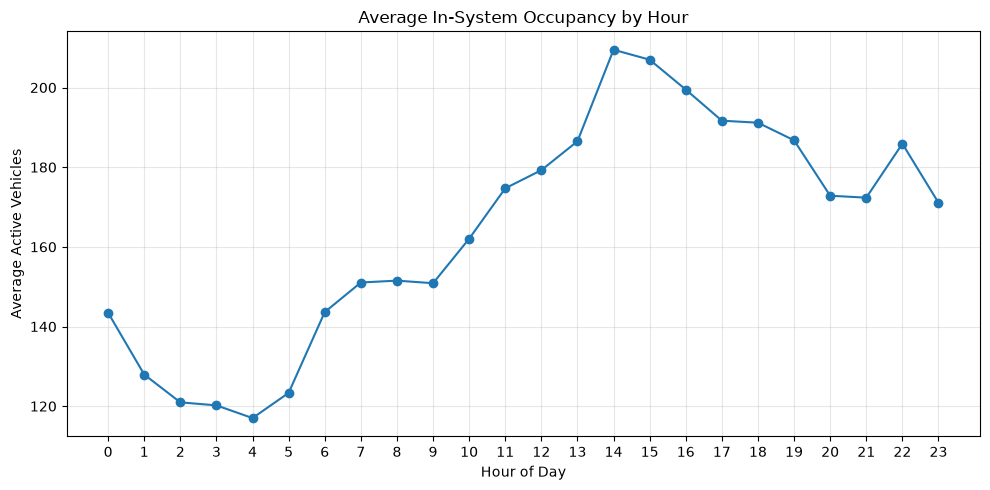

In [56]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_occupancy.index,
    hourly_occupancy["average_occupancy"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Active Vehicles")
plt.title("Average In-System Occupancy by Hour")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Average Occupancy by Hour

The reconstructed active-vehicle series was aggregated by hour to examine the typical intraday occupancy pattern.

The highest average occupancy was observed during **14:00–14:59**, with approximately **209 active vehicles**. This occurs later than the highest average arrival hour, which was observed during **12:00–12:59**.

The difference between arrival and occupancy peaks indicates that the number of vehicles currently inside the system cannot be inferred from arrivals alone. Occupancy also depends on vehicle departures and the duration for which vehicles remain inside the system.

The absolute maximum reconstructed occupancy was **493 vehicles**, observed during the 19:00 hour. This represents an observed peak rather than the typical occupancy for that hour.

### 6.3 Arrivals, Exits, and Net Flow

To understand changes in active-vehicle occupancy, arrival and exit flows were compared across the day.

For each 15-minute interval:

\[
\text{Net Flow} = \text{Arrivals} - \text{Exits}
\]

A positive net flow indicates that more vehicles entered than exited during the interval, causing occupancy to increase. A negative net flow indicates that exits exceeded arrivals, causing occupancy to decrease.

Hourly averages of arrivals, exits, and net flow were calculated using the complete observation days.

This analysis helps explain the relationship between vehicle demand and the resulting in-system occupancy pattern.

In [57]:
complete_dates = set(complete_day_df["Entry Date"])

interval_start = (
    occupancy_15min.index - pd.Timedelta(minutes=15)
)

occupancy_analysis = occupancy_15min[
    pd.Series(
        interval_start.date,
        index=occupancy_15min.index
    ).isin(complete_dates)
]

print("Intervals used:", len(occupancy_analysis))
print(
    "Date range:",
    interval_start[occupancy_15min.index.get_indexer(occupancy_analysis.index)[0]],
    "->",
    interval_start[occupancy_15min.index.get_indexer(occupancy_analysis.index)[-1]]
)

Intervals used: 4416
Date range: 2026-08-01 00:00:00 -> 2026-09-17 23:45:00


In [58]:
interval_start = (
    occupancy_analysis.index
    - pd.Timedelta(minutes=15)
)

hourly_flow = (
    occupancy_analysis
    .assign(
        date=interval_start.date,
        hour=interval_start.hour
    )
    .groupby(["date", "hour"])[
        ["arrivals", "exits", "net_flow"]
    ]
    .sum()
)

hourly_flow_avg = (
    hourly_flow
    .groupby("hour")
    .mean()
    .round(2)
)

display(hourly_flow_avg)

print("\nHours with positive average net flow:")
display(
    hourly_flow_avg[
        hourly_flow_avg["net_flow"] > 0
    ]
)

print("\nHours with negative average net flow:")
display(
    hourly_flow_avg[
        hourly_flow_avg["net_flow"] < 0
    ]
)

,arrivals,exits,net_flow
hour,,,
0,50.87,74.13,-23.26
1,57.59,66.41,-8.83
2,55.67,58.02,-2.35
3,56.26,56.43,-0.17
4,47.33,48.65,-1.33
5,44.61,34.85,9.76
6,61.61,40.02,21.59
7,67.80,58.80,9.00
8,59.91,64.80,-4.89



Hours with positive average net flow:


,arrivals,exits,net_flow
hour,,,
5,44.61,34.85,9.76
6,61.61,40.02,21.59
7,67.80,58.80,9.00
9,68.52,68.17,0.35
10,87.65,73.98,13.67
11,89.07,79.30,9.76
12,90.85,89.65,1.20
13,86.54,75.50,11.04
14,87.35,68.67,18.67



Hours with negative average net flow:


,arrivals,exits,net_flow
hour,,,
0,50.87,74.13,-23.26
1,57.59,66.41,-8.83
2,55.67,58.02,-2.35
3,56.26,56.43,-0.17
4,47.33,48.65,-1.33
8,59.91,64.80,-4.89
15,87.59,91.30,-3.72
16,73.22,81.93,-8.72
17,83.41,89.52,-6.11


In [59]:
interval_start = (
    occupancy_analysis.index
    - pd.Timedelta(minutes=15)
)

occupancy_with_date = occupancy_analysis.copy()
occupancy_with_date["date"] = interval_start.date

daily_occupancy = (
    occupancy_with_date
    .groupby("date")["active_vehicles"]
    .agg(
        average_occupancy="mean",
        maximum_occupancy="max"
    )
)

peak_time = (
    occupancy_with_date
    .loc[
        occupancy_with_date.groupby("date")["active_vehicles"].idxmax(),
        ["date"]
    ]
)

peak_time["peak_hour"] = (
    occupancy_with_date.loc[
        occupancy_with_date.groupby("date")["active_vehicles"].idxmax()
    ].index.hour
)

daily_occupancy["peak_hour"] = peak_time.set_index("date")["peak_hour"]

display(daily_occupancy.head(10))

,average_occupancy,maximum_occupancy,peak_hour
date,,,
2026-08-01,146.750000,257.0,15
2026-08-02,181.093750,295.0,17
2026-08-03,152.385417,312.0,18
2026-08-04,206.125000,394.0,16
2026-08-05,253.229167,402.0,15
2026-08-06,216.895833,325.0,0
2026-08-07,350.208333,493.0,19
2026-08-08,155.177083,357.0,0
2026-08-09,119.364583,171.0,22


In [60]:
print("Daily maximum occupancy:")
display(
    daily_occupancy["maximum_occupancy"]
    .describe()
    .round(2)
)

print("\nMost common peak occupancy hours:")
print(
    daily_occupancy["peak_hour"]
    .value_counts()
    .sort_index()
)

print("\nHighest occupancy days:")
display(
    daily_occupancy
    .sort_values("maximum_occupancy", ascending=False)
    .head(10)
)

Daily maximum occupancy:


count     46.00
mean     270.96
std       75.11
min      154.00
25%      206.75
50%      266.00
75%      311.75
max      493.00
Name: maximum_occupancy, dtype: float64


Most common peak occupancy hours:
peak_hour
0     6
1     1
6     1
8     2
12    1
13    2
14    7
15    3
16    6
17    1
18    4
19    5
20    1
22    4
23    2
Name: count, dtype: int64

Highest occupancy days:


,average_occupancy,maximum_occupancy,peak_hour
date,,,
2026-08-07,350.208333,493.0,19
2026-08-20,297.416667,428.0,6
2026-08-05,253.229167,402.0,15
2026-08-04,206.125000,394.0,16
2026-08-19,267.375000,363.0,16
2026-08-08,155.177083,357.0,0
2026-09-17,148.322917,349.0,0
2026-08-16,216.145833,332.0,18
2026-08-06,216.895833,325.0,0


### 6.4 Daily Occupancy Peak Behavior

Daily occupancy statistics show substantial variation in both the level and timing of peak in-system occupancy.

Although the overall hourly average occupancy was highest around 14:00, individual daily occupancy peaks occurred across a much wider range of hours. This indicates that the timing of the occupancy peak is not fixed from day to day.

Some days reached their highest observed occupancy around midnight, which can occur because active vehicles remain in the system across calendar-day boundaries. This further demonstrates that occupancy reflects the accumulated state of the system rather than only the current arrival rate.

In [61]:
interval_start = (
    occupancy_analysis.index
    - pd.Timedelta(minutes=15)
)

occupancy_weekday = occupancy_analysis.copy()

occupancy_weekday["day"] = interval_start.day_name()

weekday_occupancy = (
    occupancy_weekday
    .groupby("day")["active_vehicles"]
    .agg(
        average_occupancy="mean",
        maximum_occupancy="max"
    )
    .reindex(day_order)
    .round(2)
)

display(weekday_occupancy)

,average_occupancy,maximum_occupancy
day,,
Monday,136.10,312.0
Tuesday,164.78,394.0
Wednesday,184.58,402.0
Thursday,176.15,428.0
Friday,201.12,493.0
Saturday,134.71,357.0
Sunday,154.43,332.0


### 6.5 Weekday Demand vs Occupancy

Average arrival volume and average active-vehicle occupancy were compared by day of week.

The weekday patterns are not identical. Tuesday had the highest average arrival volume, whereas Friday had the highest average occupancy.

This indicates that occupancy is not determined by incoming vehicle volume alone. The difference is consistent with the role of vehicle exits and dwell duration in determining how many vehicles remain inside the system at a given time.

The comparison is descriptive and does not establish a causal relationship between risk category, dwell time, arrivals, or occupancy.

In [62]:
weekday_comparison = (
    weekday_arrivals[["average_arrivals"]]
    .join(
        weekday_occupancy[["average_occupancy", "maximum_occupancy"]]
    )
)

display(weekday_comparison.round(2))

,average_arrivals,average_occupancy,maximum_occupancy
Entry Day,,,
Monday,1587.43,136.10,312.0
Tuesday,1792.00,164.78,394.0
Wednesday,1777.00,184.58,402.0
Thursday,1697.57,176.15,428.0
Friday,1725.83,201.12,493.0
Saturday,1432.67,134.71,357.0
Sunday,1681.00,154.43,332.0


In [63]:
print("Ranking by average arrivals:")
display(
    weekday_comparison["average_arrivals"]
    .sort_values(ascending=False)
)

print("\nRanking by average occupancy:")
display(
    weekday_comparison["average_occupancy"]
    .sort_values(ascending=False)
)

Ranking by average arrivals:


Entry Day
Tuesday      1792.00
Wednesday    1777.00
Friday       1725.83
Thursday     1697.57
Sunday       1681.00
Monday       1587.43
Saturday     1432.67
Name: average_arrivals, dtype: float64


Ranking by average occupancy:


Entry Day
Friday       201.12
Wednesday    184.58
Thursday     176.15
Tuesday      164.78
Sunday       154.43
Monday       136.10
Saturday     134.71
Name: average_occupancy, dtype: float64

## 7. Demand vs Congestion

Active-vehicle occupancy was compared with vehicle arrival demand to examine whether incoming traffic volume alone is sufficient to explain the observed occupancy state.

Because occupancy represents the accumulated number of vehicles remaining inside the system, it can be influenced by both arrivals and departures. Therefore, daily arrival volume and daily occupancy were compared to identify cases where the two measures did not move in the same direction.

The comparison is descriptive and is intended to identify patterns that may be relevant to the forecasting problem. It does not establish causal relationships.

### 7.1 High-Demand and High-Occupancy Mismatch Days

Complete days were classified relative to the median daily arrival volume and median daily average occupancy.

This was used to identify:

- days with relatively high arrival demand but relatively low occupancy
- days with relatively low arrival demand but relatively high occupancy

Such cases are useful for determining whether occupancy contains information beyond the contemporaneous arrival volume, particularly through the accumulation and departure of previously arrived vehicles.

In [64]:
daily_comparison = (
    daily_arrivals
    .to_frame("arrivals")
    .join(daily_occupancy[["average_occupancy", "maximum_occupancy"]])
)

print("Median daily arrivals:",
      daily_comparison["arrivals"].median())

print("Median daily average occupancy:",
      daily_comparison["average_occupancy"].median())

display(daily_comparison.head())

Median daily arrivals: 1702.0
Median daily average occupancy: 154.609375


,arrivals,average_occupancy,maximum_occupancy
Entry Date,,,
2026-08-01,1480,146.750000,257.0
2026-08-02,1707,181.093750,295.0
2026-08-03,1577,152.385417,312.0
2026-08-04,1664,206.125000,394.0
2026-08-05,1701,253.229167,402.0


In [65]:
arrival_median = daily_comparison["arrivals"].median()
occupancy_median = daily_comparison["average_occupancy"].median()

high_arrival_low_occupancy = daily_comparison[
    (daily_comparison["arrivals"] > arrival_median) &
    (daily_comparison["average_occupancy"] < occupancy_median)
].sort_values("arrivals", ascending=False)

low_arrival_high_occupancy = daily_comparison[
    (daily_comparison["arrivals"] < arrival_median) &
    (daily_comparison["average_occupancy"] > occupancy_median)
].sort_values("average_occupancy", ascending=False)

print("\nHigh arrivals + low occupancy:")
display(high_arrival_low_occupancy)

print("\nLow arrivals + high occupancy:")
display(low_arrival_high_occupancy)


High arrivals + low occupancy:


,arrivals,average_occupancy,maximum_occupancy
Entry Date,,,
2026-08-11,1942,140.239583,231.0
2026-08-12,1916,122.843750,174.0
2026-08-10,1844,120.864583,175.0
2026-09-17,1821,148.322917,349.0
2026-09-09,1820,154.479167,226.0
2026-08-09,1768,119.364583,171.0
2026-08-26,1731,147.552083,249.0
2026-08-25,1707,129.177083,205.0
2026-09-16,1703,143.760417,269.0



Low arrivals + high occupancy:


,arrivals,average_occupancy,maximum_occupancy
Entry Date,,,
2026-08-07,1685,350.208333,493.0
2026-08-05,1701,253.229167,402.0
2026-08-06,1671,216.895833,325.0
2026-08-04,1664,206.125000,394.0
2026-09-15,1700,190.052083,294.0
2026-09-06,1682,177.125000,302.0
2026-09-14,1519,155.802083,291.0
2026-08-08,1610,155.177083,357.0
2026-08-17,1623,154.739583,249.0


In [67]:
daily_flow = (
    occupancy_analysis
    .groupby(
        (occupancy_analysis.index - pd.Timedelta(minutes=15)).date
    )[["arrivals", "exits", "net_flow"]]
    .sum()
)

daily_dwell = (
    complete_day_df
    .groupby("Entry Date")["Duration in Min"]
    .mean()
    .rename("average_dwell")
)

daily_detail = (
    daily_flow
    .join(daily_dwell)
    .join(
        daily_occupancy[
            ["average_occupancy", "maximum_occupancy"]
        ]
    )
)

selected_dates = (
    list(high_arrival_low_occupancy.index)
    + list(low_arrival_high_occupancy.index)
)

selected_dates = list(dict.fromkeys(selected_dates))

display(
    daily_detail
    .loc[selected_dates]
    .sort_values("average_occupancy")
    .round(2)
)

,arrivals,exits,net_flow,average_dwell,average_occupancy,maximum_occupancy
2026-08-09,1768.0,1849.0,-81.0,92.39,119.36,171.0
2026-08-10,1844.0,1778.0,66.0,95.56,120.86,175.0
2026-08-12,1916.0,1859.0,57.0,92.52,122.84,174.0
2026-08-25,1707.0,1802.0,-95.0,106.95,129.18,205.0
2026-08-11,1942.0,2004.0,-62.0,101.99,140.24,231.0
2026-09-16,1703.0,1839.0,-136.0,105.75,143.76,269.0
2026-08-26,1731.0,1742.0,-11.0,118.06,147.55,249.0
2026-09-17,1821.0,1588.0,233.0,142.54,148.32,349.0
2026-09-09,1820.0,1825.0,-5.0,122.53,154.48,226.0
2026-08-17,1623.0,1736.0,-113.0,127.11,154.74,249.0


In [68]:
# Recreate event-level cumulative occupancy
events = pd.concat(
    [
        df[["Entry Time"]].rename(columns={"Entry Time": "timestamp"}).assign(change=1),
        df[["Exit Time"]].rename(columns={"Exit Time": "timestamp"}).assign(change=-1)
    ],
    ignore_index=True
)

events = (
    events
    .groupby("timestamp")["change"]
    .sum()
    .sort_index()
)

events = events.cumsum()

# Starting and ending occupancy for each complete day
daily_state = []

for date in sorted(complete_dates):
    day_start = pd.Timestamp(date)
    next_day = day_start + pd.Timedelta(days=1)

    start_occupancy = events[
        events.index < day_start
    ].iloc[-1] if (events.index < day_start).any() else 0

    end_occupancy = events[
        events.index < next_day
    ].iloc[-1]

    daily_state.append({
        "date": date,
        "starting_occupancy": start_occupancy,
        "ending_occupancy": end_occupancy
    })

daily_state = pd.DataFrame(daily_state).set_index("date")

daily_detail_2 = (
    daily_detail
    .join(daily_state)
)

display(
    daily_detail_2.loc[selected_dates]
    .sort_values("average_occupancy")
    .round(2)
)

,arrivals,exits,net_flow,average_dwell,average_occupancy,maximum_occupancy,starting_occupancy,ending_occupancy
2026-08-09,1768.0,1849.0,-81.0,92.39,119.36,171.0,167,86
2026-08-10,1844.0,1778.0,66.0,95.56,120.86,175.0,86,152
2026-08-12,1916.0,1859.0,57.0,92.52,122.84,174.0,90,147
2026-08-25,1707.0,1802.0,-95.0,106.95,129.18,205.0,208,113
2026-08-11,1942.0,2004.0,-62.0,101.99,140.24,231.0,152,90
2026-09-16,1703.0,1839.0,-136.0,105.75,143.76,269.0,252,116
2026-08-26,1731.0,1742.0,-11.0,118.06,147.55,249.0,113,102
2026-09-17,1821.0,1588.0,233.0,142.54,148.32,349.0,116,349
2026-09-09,1820.0,1825.0,-5.0,122.53,154.48,226.0,126,121
2026-08-17,1623.0,1736.0,-113.0,127.11,154.74,249.0,213,100


### 7.2 Starting Occupancy, Flow, and Dwell Behavior

Daily starting occupancy was examined alongside arrivals, exits, net flow, and the average dwell duration of vehicles entering on each day.

The comparison shows that high arrival volume does not necessarily result in high occupancy. For example, August 11 recorded **1,942 arrivals** but had an average occupancy of only **140.24 vehicles**, while August 7 recorded fewer arrivals (**1,685**) but had a substantially higher average occupancy of **350.21 vehicles**.

August 7 also had higher starting occupancy, positive net flow, and substantially longer average dwell duration than August 11.

These observations indicate that active-vehicle occupancy reflects the accumulated state of the system and depends on multiple factors, including vehicles already inside the system, the balance between arrivals and exits, and how long vehicles remain inside.

The analysis is descriptive and does not establish that any individual factor causes the observed occupancy differences.

In [69]:
weekday_dwell = (
    complete_day_df
    .groupby("Entry Day")["Duration in Min"]
    .agg(
        count="count",
        median_dwell="median",
        p90_dwell=lambda x: x.quantile(0.90)
    )
    .reindex(day_order)
    .round(2)
)

display(weekday_dwell)

,count,median_dwell,p90_dwell
Entry Day,,,
Monday,11112,80.43,287.78
Tuesday,12544,86.93,306.71
Wednesday,12439,96.13,349.54
Thursday,11883,104.77,386.55
Friday,10355,112.78,363.06
Saturday,8596,83.50,273.24
Sunday,10086,91.48,281.44


## 8. Day-of-Week and Dwell Behavior

Weekday differences were examined not only for arrival volume and occupancy, but also for vehicle dwell behavior.

Dwell-time distributions varied across the week. Friday had the highest median dwell time at **112.78 minutes**, while Thursday had the highest P90 dwell time at **386.55 minutes**.

These differences are consistent with the observed variation in weekday occupancy. However, occupancy is influenced by multiple factors, including the existing number of active vehicles, arrivals, exits, and dwell duration. Therefore, the weekday dwell differences are treated as descriptive evidence rather than as a causal explanation of occupancy.

The observed weekday variation suggests that temporal context and dwell behavior may both be relevant when forecasting future active-vehicle occupancy.

## 9. Forecast-Horizon Investigation

The forecasting objective is to predict future active-vehicle occupancy at different time horizons. Rather than choosing forecast horizons arbitrarily, the temporal structure of the occupancy series will first be investigated.

### 9.1 Autocorrelation and Temporal Dependence

Autocorrelation measures how strongly the occupancy at the current time is related to occupancy at a later time.

In [70]:
horizon_series = occupancy_15min.copy()

# Convert timestamp back to the interval's starting calendar date
interval_start = (
    horizon_series.index - pd.Timedelta(minutes=15)
)

# Keep only intervals belonging to the entry-observation period
horizon_series = horizon_series[
    interval_start.date <= pd.to_datetime("2026-09-17").date()
].copy()

# Mark incomplete entry dates as missing
incomplete_dates = pd.to_datetime([
    "2026-08-22",
    "2026-08-23"
]).date

incomplete_mask = pd.Series(
    interval_start.date,
    index=occupancy_15min.index
).loc[horizon_series.index].isin(incomplete_dates)

horizon_series.loc[incomplete_mask, "active_vehicles"] = pd.NA

print("Total intervals:", len(horizon_series))
print(
    "Missing occupancy intervals:",
    horizon_series["active_vehicles"].isna().sum()
)

display(horizon_series.head())

Total intervals: 4608
Missing occupancy intervals: 192


,arrivals,exits,net_flow,active_vehicles
timestamp,,,,
2026-08-01 00:15:00,17.0,0.0,17.0,17.0
2026-08-01 00:30:00,7.0,0.0,7.0,24.0
2026-08-01 00:45:00,10.0,0.0,10.0,34.0
2026-08-01 01:00:00,17.0,0.0,17.0,51.0
2026-08-01 01:15:00,27.0,0.0,27.0,78.0


In [71]:
print("Total intervals:", len(horizon_series))

print(
    "Missing occupancy intervals:",
    horizon_series["active_vehicles"].isna().sum()
)

print("\nAugust 22:")
display(
    horizon_series.loc["2026-08-22"]
    .head()
)

print("\nAugust 23:")
display(
    horizon_series.loc["2026-08-23"]
    .head()
)

Total intervals: 4608
Missing occupancy intervals: 192

August 22:


,arrivals,exits,net_flow,active_vehicles
timestamp,,,,
2026-08-22 00:00:00,9.0,19.0,-10.0,129.0
2026-08-22 00:15:00,15.0,19.0,-4.0,NaN
2026-08-22 00:30:00,10.0,16.0,-6.0,NaN
2026-08-22 00:45:00,1.0,24.0,-23.0,NaN
2026-08-22 01:00:00,9.0,5.0,4.0,NaN



August 23:


,arrivals,exits,net_flow,active_vehicles
timestamp,,,,
2026-08-23 00:00:00,0.0,0.0,0.0,NaN
2026-08-23 00:15:00,0.0,0.0,0.0,NaN
2026-08-23 00:30:00,0.0,0.0,0.0,NaN
2026-08-23 00:45:00,0.0,0.0,0.0,NaN
2026-08-23 01:00:00,0.0,0.0,0.0,NaN


In [72]:
horizon_series = occupancy_15min.copy()

# Keep the observation period through September 17
horizon_series = horizon_series[
    horizon_series.index.date <= pd.Timestamp("2026-09-17").date()
].copy()

# Incomplete calendar dates
incomplete_dates = pd.to_datetime([
    "2026-08-22",
    "2026-08-23"
]).date

# Mark every 15-minute interval belonging to these dates as missing
horizon_series.loc[
    pd.Series(
        horizon_series.index.date,
        index=horizon_series.index
    ).isin(incomplete_dates),
    "active_vehicles"
] = pd.NA

print("Total intervals:", len(horizon_series))

print(
    "Missing occupancy intervals:",
    horizon_series["active_vehicles"].isna().sum()
)

print("\nAugust 22:")
display(horizon_series.loc["2026-08-22"].head())

print("\nAugust 23:")
display(horizon_series.loc["2026-08-23"].head())

Total intervals: 4607
Missing occupancy intervals: 192

August 22:


,arrivals,exits,net_flow,active_vehicles
timestamp,,,,
2026-08-22 00:00:00,9.0,19.0,-10.0,NaN
2026-08-22 00:15:00,15.0,19.0,-4.0,NaN
2026-08-22 00:30:00,10.0,16.0,-6.0,NaN
2026-08-22 00:45:00,1.0,24.0,-23.0,NaN
2026-08-22 01:00:00,9.0,5.0,4.0,NaN



August 23:


,arrivals,exits,net_flow,active_vehicles
timestamp,,,,
2026-08-23 00:00:00,0.0,0.0,0.0,NaN
2026-08-23 00:15:00,0.0,0.0,0.0,NaN
2026-08-23 00:30:00,0.0,0.0,0.0,NaN
2026-08-23 00:45:00,0.0,0.0,0.0,NaN
2026-08-23 01:00:00,0.0,0.0,0.0,NaN


## Autocorrelation at Candidate Horizons
What we're trying to find

We want to measure how related occupancy is to itself at different future distances:

In [73]:
occupancy_series = horizon_series["active_vehicles"].astype("float64")

horizons = {
    "15 min": 1,
    "30 min": 2,
    "1 hour": 4,
    "2 hours": 8,
    "3 hours": 12,
    "4 hours": 16,
    "6 hours": 24,
    "24 hours": 96,
    "7 days": 672
}

results = []

for horizon, lag in horizons.items():
    shifted = occupancy_series.shift(lag)

    valid_pairs = (
        occupancy_series.notna()
        & shifted.notna()
    ).sum()

    autocorrelation = occupancy_series.autocorr(lag=lag)

    results.append({
        "horizon": horizon,
        "lag_steps": lag,
        "autocorrelation": autocorrelation,
        "valid_pairs": valid_pairs
    })

autocorrelation_results = pd.DataFrame(results)

display(
    autocorrelation_results.round(4)
)

,horizon,lag_steps,autocorrelation,valid_pairs
0,15 min,1,0.9897,4413
1,30 min,2,0.9723,4411
2,1 hour,4,0.9304,4407
3,2 hours,8,0.8363,4399
4,3 hours,12,0.7427,4391
5,4 hours,16,0.6512,4383
6,6 hours,24,0.4776,4367
7,24 hours,96,0.3315,4223
8,7 days,672,-0.0654,3551


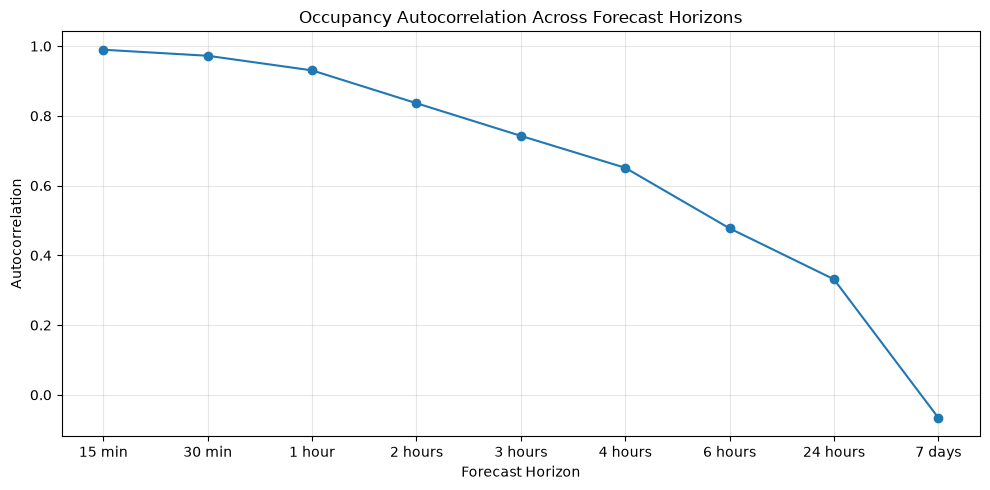

In [74]:
plt.figure(figsize=(10, 5))

plt.plot(
    autocorrelation_results["horizon"],
    autocorrelation_results["autocorrelation"],
    marker="o"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Autocorrelation")
plt.title("Occupancy Autocorrelation Across Forecast Horizons")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9.2 Autocorrelation Results

The occupancy series shows very strong short-term temporal dependence. Autocorrelation remains high at 15 minutes (0.9897), 30 minutes (0.9723), and 1 hour (0.9304), and remains substantial at 2 hours (0.8363) and 3 hours (0.7427).

The relationship weakens at longer horizons, declining to 0.6512 at 4 hours and 0.4776 at 6 hours.

At a 24-hour lag, the autocorrelation is 0.3315, indicating that some same-time-next-day relationship remains, although it is substantially weaker than the short-term relationship.

The 7-day autocorrelation is -0.0654, which is close to zero. Therefore, no strong same-time weekly autocorrelation is observed in this dataset. This does not prove that weekly seasonality is absent; it only indicates that a simple 7-day lag correlation is weak in the available sample.

### 9.3 Implications for Candidate Forecast Horizons

The autocorrelation analysis suggests that short-term horizons such as **15 minutes, 30 minutes, 1 hour, 2 hours, and 3 hours** have strong temporal dependence and are reasonable candidates for subsequent forecasting evaluation.

Longer horizons such as 4–6 hours show weaker temporal persistence and should be evaluated separately rather than assumed to be equally predictable.

The 24-hour relationship indicates some daily temporal structure but is not strong enough to infer high forecasting accuracy from persistence alone.

Autocorrelation is used here only to investigate temporal dependence. Final forecasting horizons will be selected using a combination of business relevance and chronological out-of-sample model performance.

## 10. Final EDA — Key Findings

The exploratory analysis was conducted to understand the vehicle-entry system and identify patterns relevant to forecasting future in-system occupancy.

### Data Quality

The dataset contains **77,432 vehicle records**. The core `Entry Time` and `Exit Time` fields are complete, with no missing timestamps, invalid entry-exit ordering, non-positive dwell durations, complete duplicate rows, or repeated entry-exit event pairs identified.

The vehicle-identification fields (`Country`, `Plate Prefix`, and `Plate Number`) contained no usable information and were excluded from further analysis.

`Risk Category` was available for approximately two-thirds of the records, with `GREEN`, `RED`, and missing values observed. Missing categories will be represented as `UNKNOWN` rather than removing the corresponding vehicle records.

Two dates, **August 22 and August 23, 2026**, showed clear evidence of incomplete entry coverage and were therefore excluded from analyses requiring complete daily observations.

### Dwell-Time Behavior

Vehicle dwell time is strongly right-skewed. The median dwell time was **93.13 minutes**, compared with a mean of **142.47 minutes**, with the difference caused by the presence of longer-duration vehicles.

The upper tail is substantial:

- P90 = **327.98 minutes**
- P95 = **471.50 minutes**
- P99 = **655.15 minutes**
- Maximum = **719.98 minutes**

An apparent upper boundary near 720 minutes was observed. The data alone does not establish whether this represents an operational limit, censoring, or another business rule, so these observations were retained rather than treated as invalid.

Dwell behavior also differed across risk categories. `RED` vehicles showed higher median and upper-percentile dwell times than `GREEN` vehicles, although the `RED` category contains substantially fewer observations. This makes `Risk Category` a candidate forecasting feature rather than evidence of a causal relationship.

### Arrival Demand

Daily arrival volume varied substantially across complete observation days, ranging from **1,181 to 2,173 arrivals**, with an average of **1,674.24 arrivals per day**.

A clear intraday arrival pattern was observed. The highest average arrival volume occurred during **12:00–12:59**, at approximately **90.9 arrivals**, while the lowest occurred during **05:00–05:59**, at approximately **44.6 arrivals**.

Arrival volume also differed by weekday. Tuesday had the highest observed average arrival volume at **1,792 vehicles per day**, while Saturday had the lowest at **1,432.67 vehicles per day**.

These patterns indicate that hour-of-day and day-of-week information may be useful for forecasting.

### Active Vehicle Count / In-System Occupancy

Because the dataset does not contain a direct physical queue-length measurement, active vehicle count was reconstructed from vehicle entry and exit events.

For each event:

- Entry = +1
- Exit = -1

The cumulative balance represents the number of vehicles currently inside the observed system.

This quantity is referred to as **active-vehicle count** or **in-system occupancy** and is used as a proxy for congestion/queue state. It should not be interpreted as a direct measurement of physical queue length.

The reconstructed 15-minute series contains **4,650 regular intervals**, preserves all **77,432 arrivals and 77,432 exits**, contains no missing values after aggregation, and maintains a non-negative active-vehicle count.

### Occupancy vs Arrival Demand

The occupancy pattern differs from the arrival pattern.

The highest average arrival volume occurred around **12:00**, while the highest average occupancy occurred around **14:00**, showing that the peak arrival period and peak occupancy period are not synchronized.

Average hourly net flow was positive during several late-morning and early-afternoon periods and became predominantly negative during much of the later afternoon and evening.

This demonstrates that occupancy depends on the balance between arrivals and exits rather than on incoming traffic alone.

Daily comparisons provided the same evidence. For example, **August 11** recorded **1,942 arrivals** but had an average occupancy of only **140.24 vehicles**, while **August 7** recorded fewer arrivals (**1,685**) but had substantially higher average occupancy of **350.21 vehicles**.

These differences are consistent with the additional influence of the existing occupancy state, vehicle departures, and dwell behavior.

### Weekday Occupancy and Dwell Behavior

Average occupancy differed across weekdays. Friday had the highest observed average occupancy at approximately **201 vehicles**, while Saturday had the lowest at approximately **135 vehicles**.

Dwell behavior also varied across weekdays. Friday had the highest median dwell time at **112.78 minutes**, while Thursday had the highest P90 dwell time at **386.55 minutes**.

These results indicate that temporal context and dwell behavior may both contain information relevant to occupancy forecasting.

### Forecast-Horizon Investigation

Occupancy showed very strong short-term temporal dependence:

| Horizon | Autocorrelation |
|---|---:|
| 15 minutes | 0.9897 |
| 30 minutes | 0.9723 |
| 1 hour | 0.9304 |
| 2 hours | 0.8363 |
| 3 hours | 0.7427 |
| 4 hours | 0.6512 |
| 6 hours | 0.4776 |
| 24 hours | 0.3315 |
| 7 days | -0.0654 |

The results indicate strong persistence over short horizons, with the relationship weakening progressively as the forecast horizon increases.

The results therefore provide support for evaluating **15-minute, 30-minute, 1-hour, 2-hour, and 3-hour** forecasting horizons. Longer horizons such as 4–6 hours may also be evaluated, but their weaker temporal dependence means they should not be assumed to be equally predictable.

The 24-hour autocorrelation indicates some same-time-next-day relationship, while the 7-day autocorrelation is close to zero. This does not prove that weekly seasonality is absent; it only indicates that a simple 7-day lag relationship is weak in the available sample.

Autocorrelation is used as evidence of temporal dependence, not as a direct measure of forecasting accuracy. Final forecasting horizons will be selected using business relevance and chronological out-of-sample model evaluation.

### Overall EDA Conclusion

The analysis indicates that future in-system occupancy is a state-dependent forecasting problem rather than a simple vehicle-arrival prediction problem.

Occupancy reflects:

- the current number of active vehicles
- incoming vehicle flow
- outgoing vehicle flow
- dwell behavior
- time-of-day patterns
- weekday effects

The strong short-term persistence of occupancy makes near-term forecasting particularly relevant, while the weakening relationship at longer horizons indicates increasing uncertainty as the prediction horizon expands.

These findings provide the basis for the next phase: constructing a separate, deterministic feature-transformation pipeline that converts the vehicle-level records into ML-ready time-series data without introducing future information into the features.